**Description:**

Here

# Imports

In [ ]:
%pip install scikit-learn dune-client web3

In [19]:
import os
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta, timezone

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, roc_auc_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import learning_curve
from sklearn.ensemble import RandomForestClassifier

from dune_client.client import DuneClient
from dune_client.query import QueryBase
from dune_client.types import QueryParameter
from web3 import Web3

# Concatenate datasets

In [3]:
v1_ml_df = pd.read_csv('../media/ML/balancer_v1_ml_training_data.csv')
v2_ml_df = pd.read_csv('../media/ML/balancer_v2_ml_training_data.csv')

v1v2_ml_df = pd.concat([v1_ml_df, v2_ml_df], ignore_index=True)

v1v2_ml_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 401 entries, 0 to 400
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   duration_h                   401 non-null    float64
 1   start_weight_proj            401 non-null    float64
 2   end_weight_proj              401 non-null    float64
 3   weight_slope                 401 non-null    float64
 4   initial_fdv_usd              401 non-null    float64
 5   is_missing_fdv               401 non-null    int64  
 6   swap_fee_pct                 401 non-null    float64
 7   collateral_is_stable         401 non-null    int64  
 8   is_weekend                   401 non-null    int64  
 9   hour_of_day                  401 non-null    int64  
 10  weekend_pct                  401 non-null    float64
 11  price_found_success          401 non-null    int64  
 12  consistent_activity_success  401 non-null    int64  
 13  not_bot_success     

In [4]:
# Evaluate the success labeled columns distribution
print("\nSuccess Distribution:")
print(v1v2_ml_df['price_found_success'].value_counts(normalize=True))
print(v1v2_ml_df['consistent_activity_success'].value_counts(normalize=True))
print(v1v2_ml_df['not_bot_success'].value_counts(normalize=True))
print(v1v2_ml_df['final_success'].value_counts(normalize=True))


Success Distribution:
price_found_success
0    0.862843
1    0.137157
Name: proportion, dtype: float64
consistent_activity_success
1    0.683292
0    0.316708
Name: proportion, dtype: float64
not_bot_success
1    0.890274
0    0.109726
Name: proportion, dtype: float64
final_success
0    0.917706
1    0.082294
Name: proportion, dtype: float64


# Stratified split and scaling

In [15]:
# 1. PREPARE FEATURES (X) AND TARGET (y)
# We drop all success columns from X to prevent data leakage.
# We select 'final_success' as the target for this run.
drop_cols = ['price_found_success', 'consistent_activity_success', 
             'not_bot_success', 'final_success']

extra_drop_cols = ['hour_of_day','is_weekend']  

X = v1v2_ml_df.drop(columns=drop_cols+extra_drop_cols)
y = v1v2_ml_df['final_success']

# ---------------------------------------------------------
# STEP 2: STRATIFIED SPLITTING
# ---------------------------------------------------------
# Why: Random split might result in a test set with 0 successes 
# because you only have ~8% positive class. Stratified ensures 
# the ratio (92/8) is preserved in both Train and Test sets.

splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_index, test_index in splitter.split(X, y):
    X_train_raw, X_test_raw = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

print(f"Train Class Dist:\n{y_train.value_counts(normalize=True)}")
print(f"Test Class Dist:\n{y_test.value_counts(normalize=True)}")
# You should see ~0.08 for class 1 in both outputs.

# ---------------------------------------------------------
# STEP 3: FEATURE SCALING (StandardScaler)
# ---------------------------------------------------------
# Why: Logistic Regression is sensitive to the scale of input data. 
# 'initial_fdv_usd' (millions) would dominate 'swap_fee_pct' (decimals) 
# without scaling.

scaler = StandardScaler()

# CRITICAL: Fit ONLY on X_train to avoid "Data Leakage". 
# Then transform both X_train and X_test using that fit.
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# ---------------------------------------------------------
# STEP 1: DEFINE METRICS (Setup for later)
# ---------------------------------------------------------
# Why: Accuracy is dangerous here. We prepare to use F1 and ROC-AUC.
# This snippet is just to show how you will call it after training.

def evaluate_model(y_true, y_pred, y_prob):
    print("F1 Score (Macro):", f1_score(y_true, y_pred, average='macro'))
    print("ROC-AUC Score:", roc_auc_score(y_true, y_prob))
    # 'macro' average is useful here to treat both classes as important

Train Class Dist:
final_success
0    0.91875
1    0.08125
Name: proportion, dtype: float64
Test Class Dist:
final_success
0    0.91358
1    0.08642
Name: proportion, dtype: float64


# Training

## Logistic regression

--- BASELINE (DUMMY) RESULTS ---
F1 Score (Macro): 0.4774193548387097
ROC-AUC Score: 0.5


--- LOGISTIC REGRESSION RESULTS ---
F1 Score (Macro): 0.44596443228454175
ROC-AUC Score: 0.6196911196911197


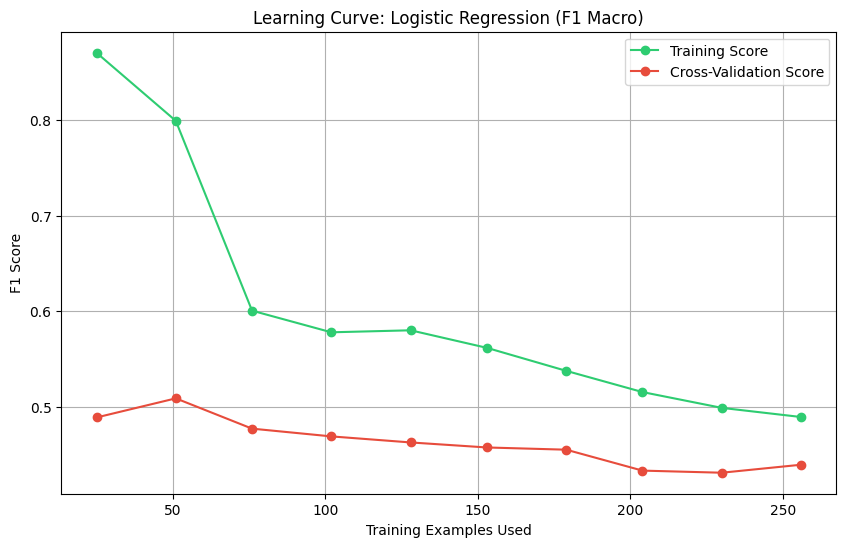

In [10]:
# ---------------------------------------------------------
# STEP 5 (Part A): ESTABLISH THE DUMMY BASELINE
# ---------------------------------------------------------
# Why: If our complex model can't beat this, it's useless.
# This "stupid" model just guesses the most frequent class (0) every time.

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train_scaled, y_train)
y_pred_dummy = dummy.predict(X_test_scaled)

print("--- BASELINE (DUMMY) RESULTS ---")
# Note: F1 for the minority class will likely be 0.0 here
evaluate_model(y_test, y_pred_dummy, dummy.predict_proba(X_test_scaled)[:, 1])
print("\n")

# ---------------------------------------------------------
# STEP 4 & 5 (Part B): TRAIN LOGISTIC REGRESSION
# ---------------------------------------------------------
# class_weight='balanced': Automatically adjusts weights inversely 
# proportional to class frequencies. (Solves the 8% imbalance issue).

model = LogisticRegression(class_weight='balanced', random_state=42)
model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1] # Probability of "Success"

print("--- LOGISTIC REGRESSION RESULTS ---")
evaluate_model(y_test, y_pred, y_prob)

# ---------------------------------------------------------
# VISUALIZATION: LEARNING CURVE
# ---------------------------------------------------------
# This answers: "Is my model learning? Would more data help?"

train_sizes, train_scores, test_scores = learning_curve(
    model, X_train_scaled, y_train, cv=5, scoring='f1_macro',
    n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10)
)

# Calculate means and standard deviations for plotting
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color="#2ecc71", label="Training Score")
plt.plot(train_sizes, test_mean, 'o-', color="#e74c3c", label="Cross-Validation Score")

plt.title("Learning Curve: Logistic Regression (F1 Macro)")
plt.xlabel("Training Examples Used")
plt.ylabel("F1 Score")
plt.legend(loc="best")
plt.grid(True)
plt.show()

**Conclusion:**

- Model is too simple. It cannot capture the pattern even in the training data (Green line dropped essentially to random chance).
- Model is technically "worse" than doing nothing. This happens because class_weight='balanced' forces the model to guess "Success" more often. Since the model isn't smart yet, it makes many False Positives, dragging the score down.

## Random Forest

--- RANDOM FOREST RESULTS ---
F1 Score (Macro): 0.5611077664057796
ROC-AUC Score: 0.5926640926640926


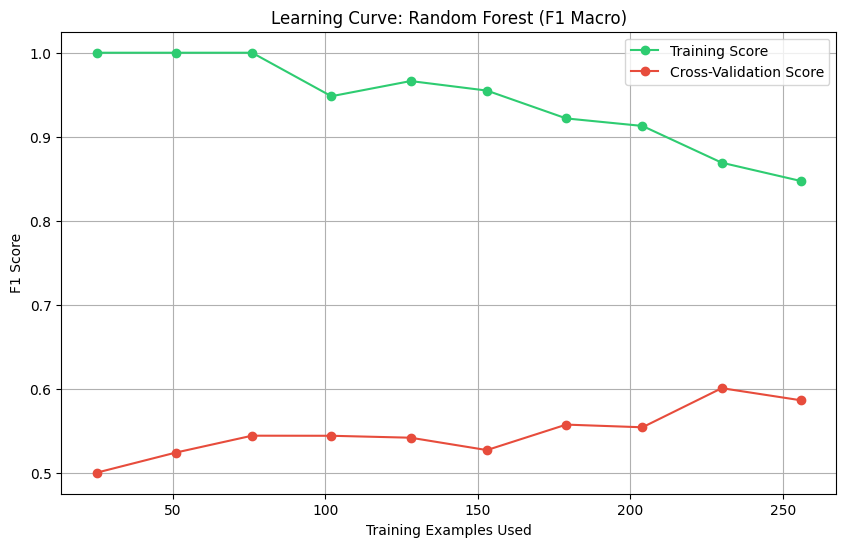

In [20]:
# 1. Update the Model Definition
# max_depth=4: Prevents the model from memorizing the tiny dataset
# class_weight='balanced': Still necessary for your 8% success rate
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5, 
    class_weight='balanced',
    random_state=42
)

# 2. Train and Evaluate (Same logic as before)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("--- RANDOM FOREST RESULTS ---")
evaluate_model(y_test, y_pred, y_prob)

# 3. Generate New Learning Curve (Reuse previous plotting code)
train_sizes, train_scores, test_scores = learning_curve(
    model, X_train_scaled, y_train, cv=5, scoring='f1_macro',
    n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10)
)

# Calculate means and standard deviations for plotting
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color="#2ecc71", label="Training Score")
plt.plot(train_sizes, test_mean, 'o-', color="#e74c3c", label="Cross-Validation Score")

plt.title("Learning Curve: Random Forest (F1 Macro)")
plt.xlabel("Training Examples Used")
plt.ylabel("F1 Score")
plt.legend(loc="best")
plt.grid(True)
plt.show()

**Overfitting:** the huge distance between the green and red lines is the definition of high variance. The model is paying attention to "noise" or "coincidences" in the training data that don't exist in the real world.

### Verify feature importance

                Feature  Importance
0            duration_h    0.228943
3          weight_slope    0.202903
8           weekend_pct    0.167935
2       end_weight_proj    0.154377
1     start_weight_proj    0.099720
6          swap_fee_pct    0.092033
7  collateral_is_stable    0.027825
5        is_missing_fdv    0.026135
4       initial_fdv_usd    0.000129


C:\Users\kaiqu\AppData\Local\Temp\ipykernel_20228\4041517791.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')


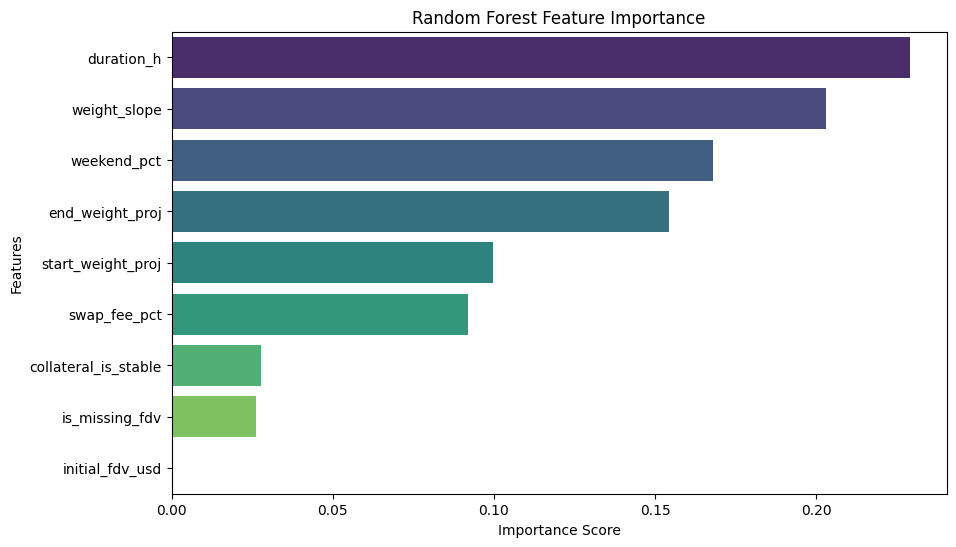

In [17]:
# ---------------------------------------------------------
# STEP 6: FEATURE IMPORTANCE ANALYSIS
# ---------------------------------------------------------

# 1. Extract Importance
importances = model.feature_importances_
feature_names = X.columns

# 2. Create a DataFrame for nice printing
feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 3. Print the raw numbers
print(feature_imp_df)

# 4. Visualize
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()